# Caracterización de jugadores según posición en el campo

**Posiciones:** GK (portero) · LW/RW (extremos) · LB/RB (laterales) · CB (central) · LP (pivote)

In [20]:
import os
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.inspection import permutation_importance
import xgboost as xgb

os.makedirs('position_output', exist_ok=True)

# ── Paleta por posición ──────────────────────────────────────
POS_COLORS = {
    'GK': '#888780',
    'LW': '#3266ad', 'RW': '#7f77dd',
    'LB': '#d85a30', 'RB': '#ba7517',
    'CB': '#1d9e75',
    'LP': '#d4537e',
}

# Agrupación semántica de posiciones para simplificar si se desea
POS_GROUP = {
    'GK': 'Portero',
    'LW': 'Extremo', 'RW': 'Extremo',
    'LB': 'Lateral', 'RB': 'Lateral',
    'CB': 'Central',
    'LP': 'Pivote',
}

#Funcion para 
def _outdir(*parts):
    path = os.path.join(*parts)
    os.makedirs(path, exist_ok=True)
    return path


## 1. Carga y preparación de datos

In [21]:
ruta_csv = 'EHF2024-M-AGGREGATED.csv'
df_raw = pd.read_csv(ruta_csv)

# Variables de rendimiento (excluir metadatos y variables derivadas)
COLS_DROP = ['Unnamed: 0', 'Team', 'No', 'Name', 'scoring', 'topk', 'top1', 'R7', 'P7']
FEATURE_COLS = [
    '7mPGoals', '7mPMissed', '6mCGoals', '6mCMissed',
    'WingGoals', 'WingMissed', 'BTGoals', 'BTMissed',
    'FBGoals', 'FBMissed', 'FTOGoals', 'FTOMissed',
    '9mGoals', '9mMissed', 'RC', '2M', '2+2',
    'AS', 'ST', 'BS', 'TO', 'Time'
]
TARGET_COL = 'Position'

df = df_raw[FEATURE_COLS + [TARGET_COL]].copy()
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip()


df = df.dropna()

print(f'Dataset: {df.shape[0]} jugadores, {len(FEATURE_COLS)} variables')
print('\nDistribución de posiciones:')
print(df[TARGET_COL].value_counts())
df['Grupo'] = df[TARGET_COL].map(POS_GROUP)

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values
y_group = df['Grupo'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)
print('\nClases:', le.classes_)

Dataset: 427 jugadores, 22 variables

Distribución de posiciones:
Position
LB    83
LP    72
CB    64
GK    56
RB    56
RW    50
LW    46
Name: count, dtype: int64

Clases: ['CB' 'GK' 'LB' 'LP' 'LW' 'RB' 'RW']


## 2. Modelos supervisados

In [22]:
# ── Train / test split estratificado ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 341  |  Test: 86


In [23]:
# ── Random Forest 
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)
acc_rf    = accuracy_score(y_test, y_pred_rf)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf, X_train_sc, y_train, cv=cv, scoring='accuracy')

print(f'Random Forest — Test accuracy : {acc_rf:.4f}')
print(f'               CV accuracy    : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest — Test accuracy : 0.5930
               CV accuracy    : 0.4634 ± 0.0278

              precision    recall  f1-score   support

          CB       0.46      0.46      0.46        13
          GK       0.65      1.00      0.79        11
          LB       0.50      0.35      0.41        17
          LP       0.72      0.87      0.79        15
          LW       0.57      0.44      0.50         9
          RB       0.57      0.36      0.44        11
          RW       0.58      0.70      0.64        10

    accuracy                           0.59        86
   macro avg       0.58      0.60      0.58        86
weighted avg       0.58      0.59      0.57        86



In [24]:
# ── XGBoost ───────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_test_sc, y_test)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test_sc)
acc_xgb    = accuracy_score(y_test, y_pred_xgb)

cv_scores_xgb = cross_val_score(xgb_model, X_train_sc, y_train, cv=cv, scoring='accuracy')

print(f'XGBoost — Test accuracy : {acc_xgb:.4f}')
print(f'          CV accuracy   : {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

XGBoost — Test accuracy : 0.5581
          CV accuracy   : 0.4458 ± 0.0298

              precision    recall  f1-score   support

          CB       0.46      0.46      0.46        13
          GK       0.85      1.00      0.92        11
          LB       0.47      0.41      0.44        17
          LP       0.92      0.80      0.86        15
          LW       0.33      0.44      0.38         9
          RB       0.36      0.36      0.36        11
          RW       0.44      0.40      0.42        10

    accuracy                           0.56        86
   macro avg       0.55      0.55      0.55        86
weighted avg       0.56      0.56      0.56        86



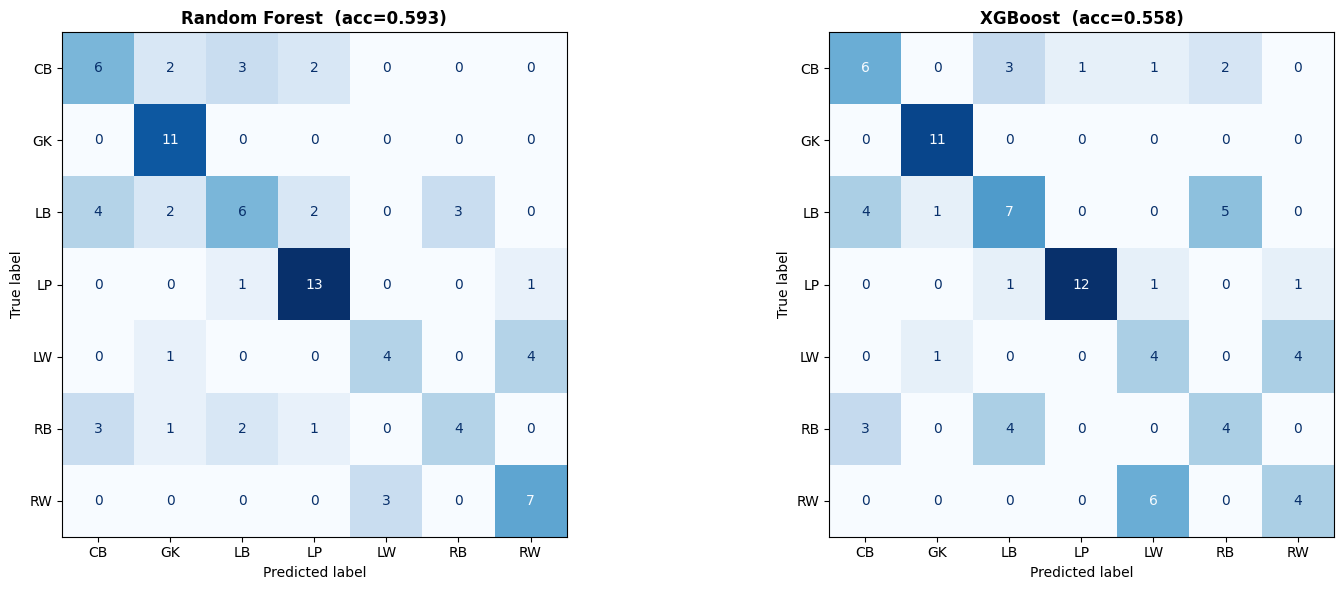

In [25]:
# ── Matrices de confusión ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_xgb],
    ['Random Forest', 'XGBoost']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}  (acc={accuracy_score(y_test, y_pred):.3f})',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
fig.savefig('position_output/confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()

In [26]:
# ── Elegir el mejor modelo para SHAP ─────────────────────────
# Al final me quedo con el modelo de Random Forest
if acc_xgb >= acc_rf:
    best_model      = xgb_model
    best_model_name = 'XGBoost'
else:
    best_model      = rf
    best_model_name = 'Random Forest'

print(f'Mejor modelo: {best_model_name}')
print(f'  RF  acc = {acc_rf:.4f}')
print(f'  XGB acc = {acc_xgb:.4f}')

Mejor modelo: Random Forest
  RF  acc = 0.5930
  XGB acc = 0.5581


## 4. SHAP values — Interpretación global y por posición

In [27]:
# ── Calcular SHAP───────────
X_all_sc = scaler.transform(X)


explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_all_sc)
# shap_values: lista de arrays
print(f'SHAP calculados. Clases: {le.classes_}')

SHAP calculados. Clases: ['CB' 'GK' 'LB' 'LP' 'LW' 'RB' 'RW']


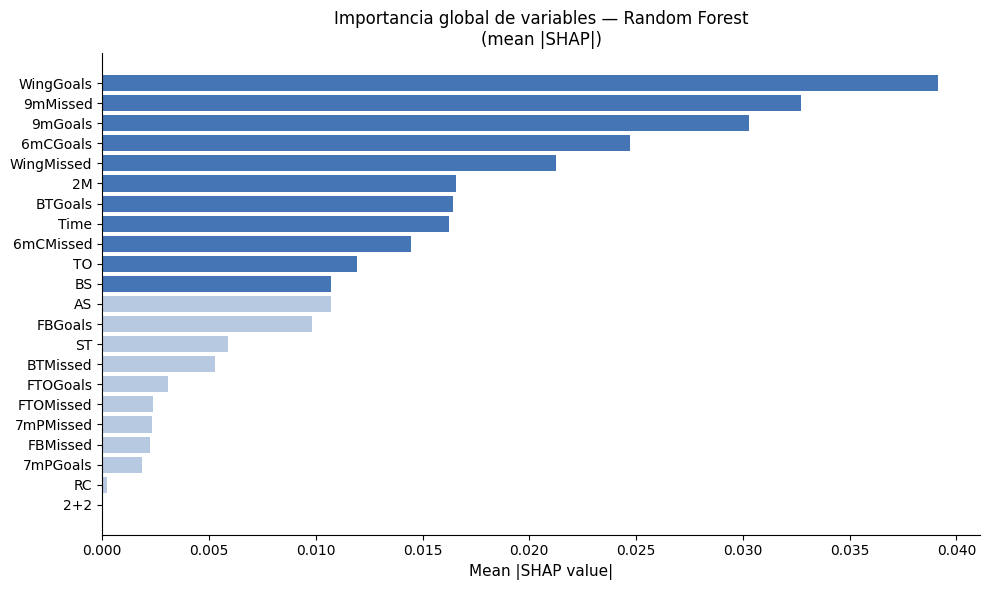

Variables más importantes (global):


,mean_abs_shap
WingGoals,0.0392
9mMissed,0.0327
9mGoals,0.0303
6mCGoals,0.0247
WingMissed,0.0212
2M,0.0165
BTGoals,0.0164
Time,0.0162
6mCMissed,0.0145
TO,0.0119


In [28]:
# ── Importancia global: mean SHAP por variable ─────────────
# Para clasificación multiclase: promedio sobre todas las clases
if isinstance(shap_values, list):
    # RandomForest devuelve una  lista
    global_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    # shape (n_samples, n_features, n_classes)
    global_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.Series(global_shap, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#3266ad' if v > shap_importance.median() else '#b0c4de'
              for v in shap_importance.values]
ax.barh(shap_importance.index[::-1], shap_importance.values[::-1],
        color=colors_bar[::-1], alpha=0.9)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title(f'Importancia global de variables — {best_model_name}\n(mean |SHAP|)',
             fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig('position_output/shap_global_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print('Variables más importantes (global):')
display(shap_importance.head(10).to_frame('mean_abs_shap').round(4))

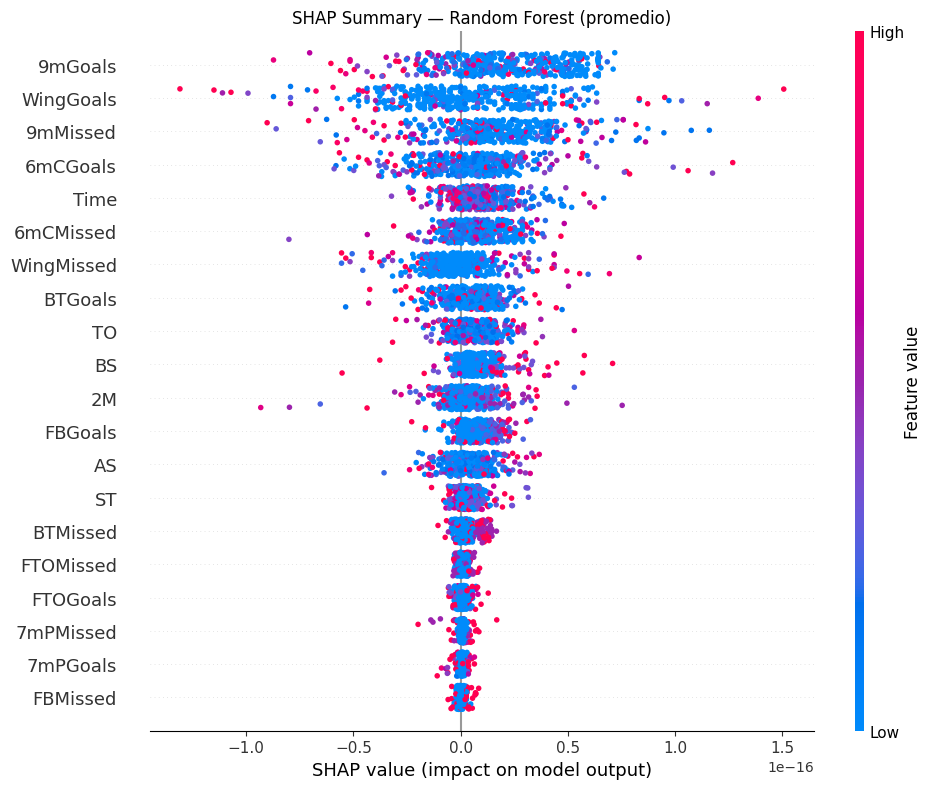

In [29]:
# ── SHAP beeswarm global──────────────────────
shap.initjs()

if isinstance(shap_values, list):
    shap_matrix = np.array(shap_values).mean(axis=0)  # promedio sobre clases
else:
    shap_matrix = shap_values.mean(axis=2) if shap_values.ndim == 3 else shap_values

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_matrix,
    features=X_all_sc,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=None
)
plt.title(f'SHAP Summary — {best_model_name} (promedio)', fontsize=12)
plt.tight_layout()
fig.savefig('position_output/shap_summary_beeswarm.png', dpi=130, bbox_inches='tight')
plt.show()

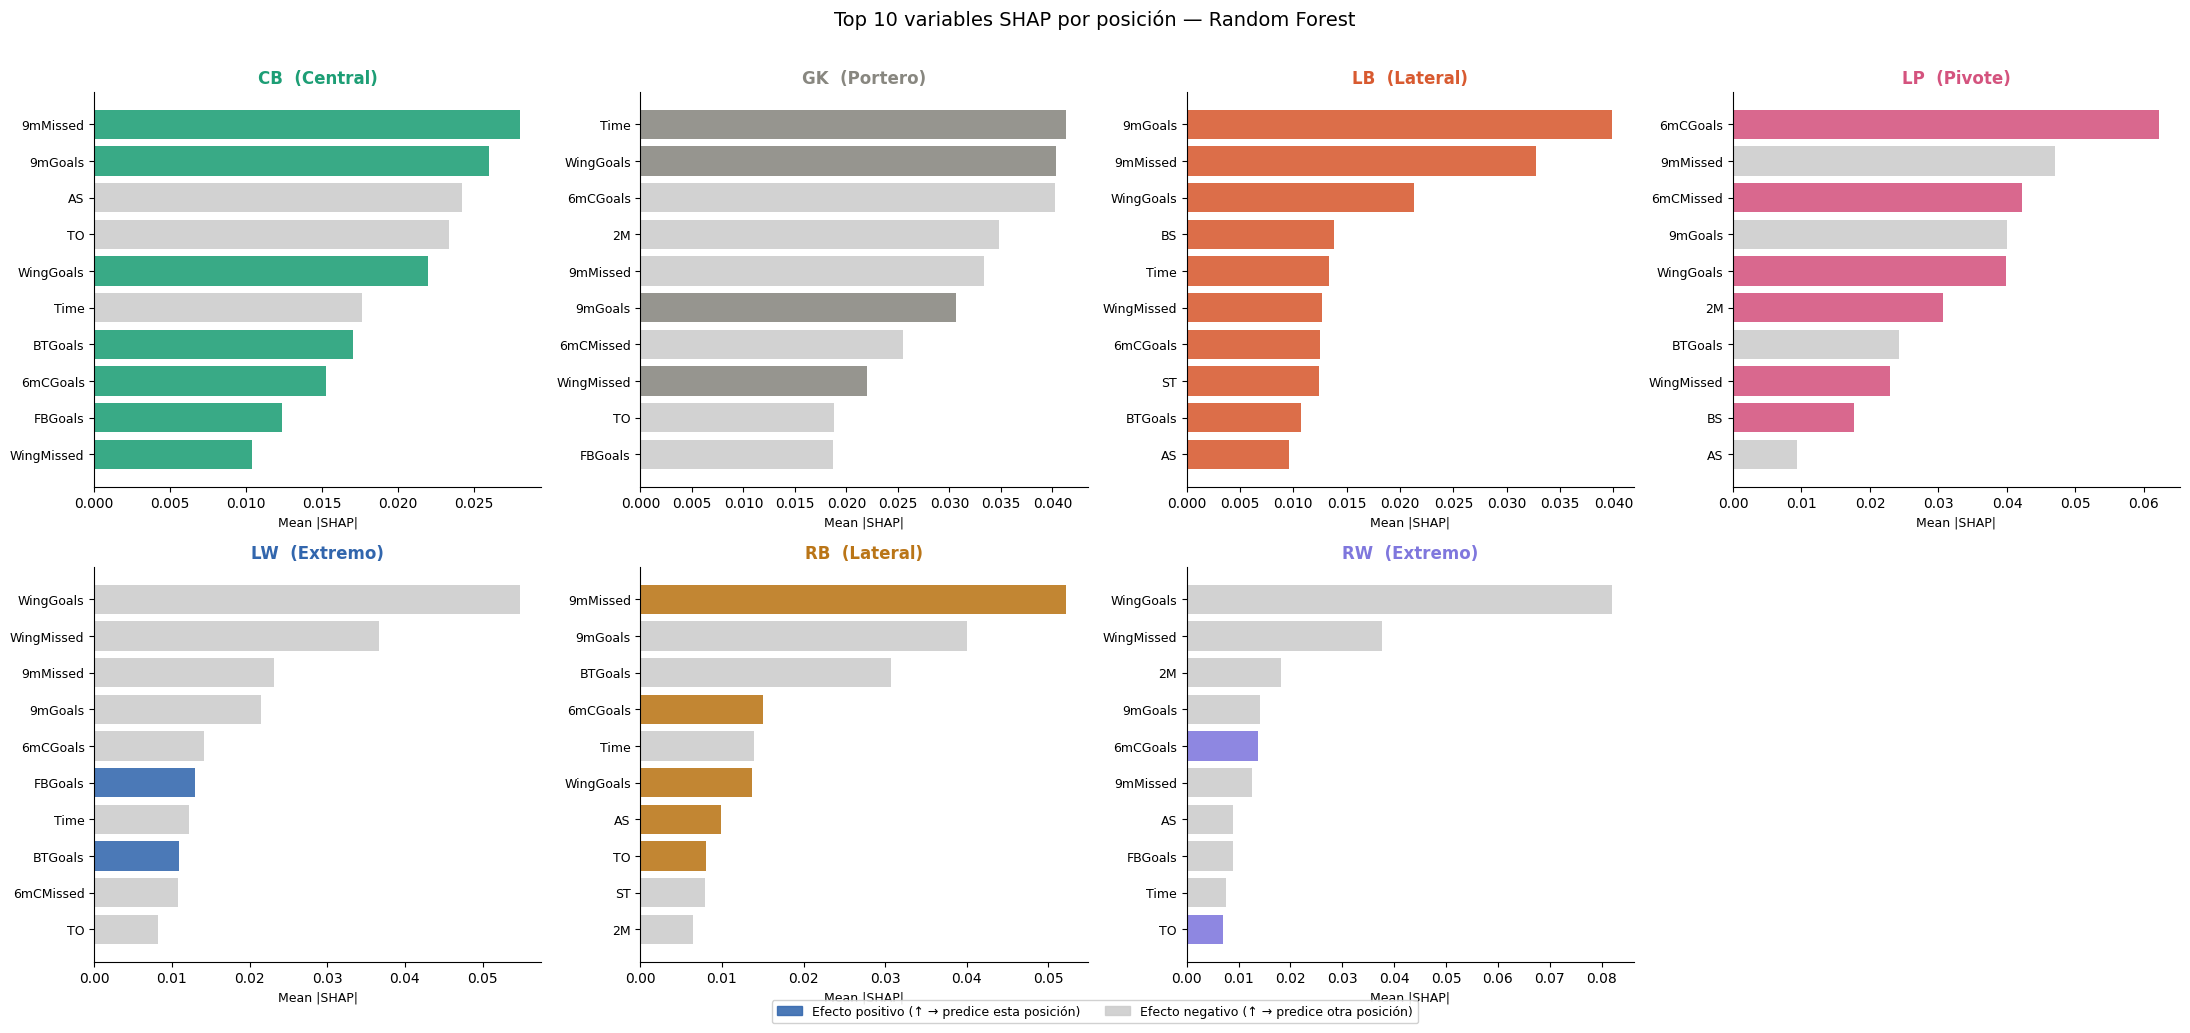

In [30]:
# ── SHAP por posición: top variables que definen cada clase ───
TOP_N    = 10
dir_shap = _outdir('position_output', 'shap_per_position')

# Normalizar shap_values a lista de arrays (n_samples, n_features) por clase
if isinstance(shap_values, list):
    shap_list = shap_values                         # RF: ya es lista
elif shap_values.ndim == 3:                         # XGB: (n_samples, n_feat, n_cls)
    shap_list = [shap_values[:, :, i]
                 for i in range(shap_values.shape[2])]
else:
    shap_list = [shap_values]

n_classes = len(le.classes_)
n_cols_p  = min(n_classes, 4)
n_rows_p  = math.ceil(n_classes / n_cols_p)

fig, axes = plt.subplots(n_rows_p, n_cols_p,
                          figsize=(n_cols_p * 5.5, n_rows_p * 5))
axes = np.array(axes).flatten()

pos_shap_summary = {}  # guardamos para la caracterización final

for idx, cls in enumerate(le.classes_):
    sv       = shap_list[idx]                      # (n_samples, n_features)
    mean_abs = np.abs(sv).mean(axis=0)
    mean_dir = sv.mean(axis=0)                     # dirección del efecto

    importance = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)
    direction  = pd.Series(mean_dir, index=FEATURE_COLS)
    top_vars   = importance.head(TOP_N)
    top_dir    = direction[top_vars.index]

    pos_shap_summary[cls] = pd.DataFrame({
        'mean_abs_shap': top_vars,
        'mean_shap': top_dir
    })

    ax      = axes[idx]
    color   = POS_COLORS.get(cls, '#888')
    bar_col = [color if d > 0 else '#cccccc' for d in top_dir.values[::-1]]

    ax.barh(range(TOP_N), top_vars.values[::-1], color=bar_col, alpha=0.88)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.set_title(f'{cls}  ({POS_GROUP.get(cls,"")})',
                 fontsize=12, fontweight='bold', color=color)
    ax.spines[['top', 'right']].set_visible(False)

    # Guardar CSV individual
    pos_shap_summary[cls].to_csv(
        os.path.join(dir_shap, f'shap_{cls}.csv')
    )

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# Leyenda de color
patch_pos = mpatches.Patch(color='#3266ad', alpha=0.88, label='Efecto positivo (↑ → predice esta posición)')
patch_neg = mpatches.Patch(color='#cccccc', alpha=0.88, label='Efecto negativo (↑ → predice otra posición)')
fig.legend(handles=[patch_pos, patch_neg], loc='lower center',
           ncol=2, fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle(f'Top {TOP_N} variables SHAP por posición — {best_model_name}',
             fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig('position_output/shap_per_position.png',
            dpi=150, bbox_inches='tight')
plt.show()

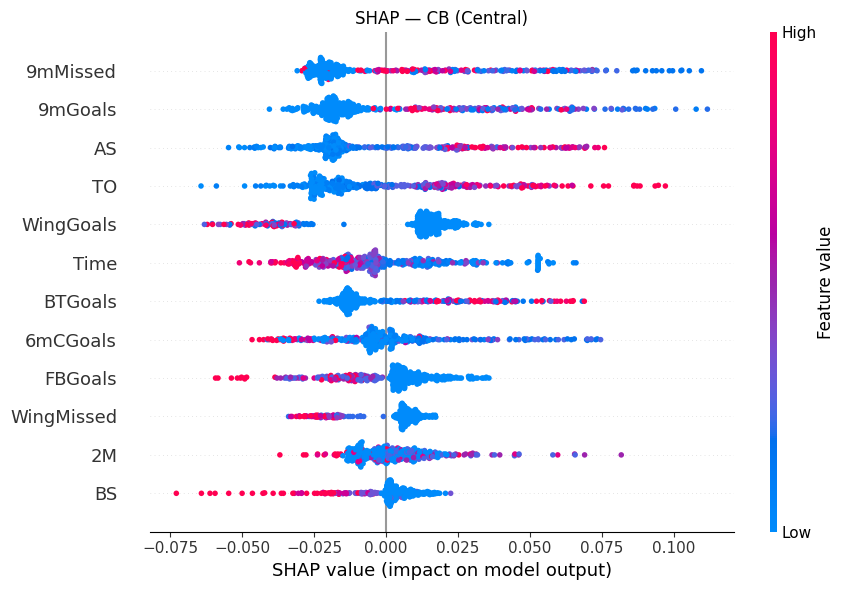

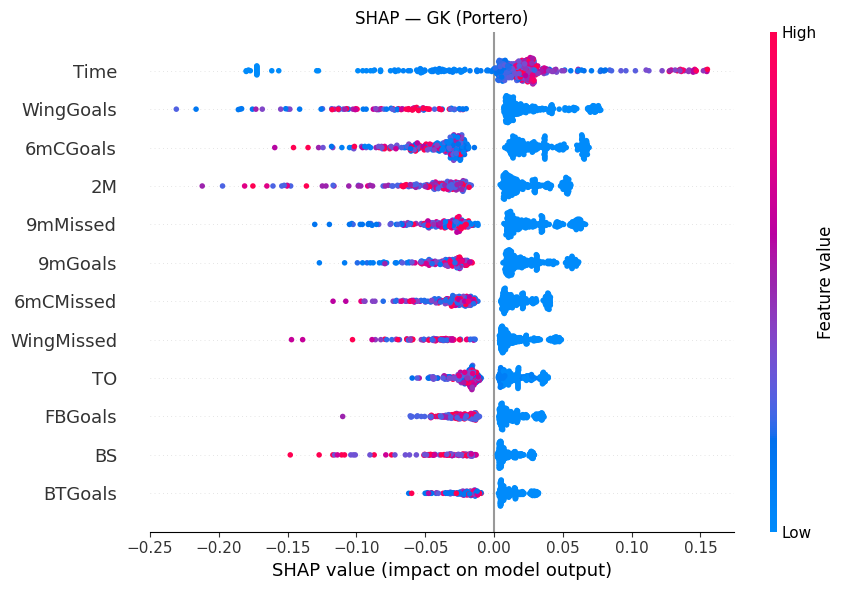

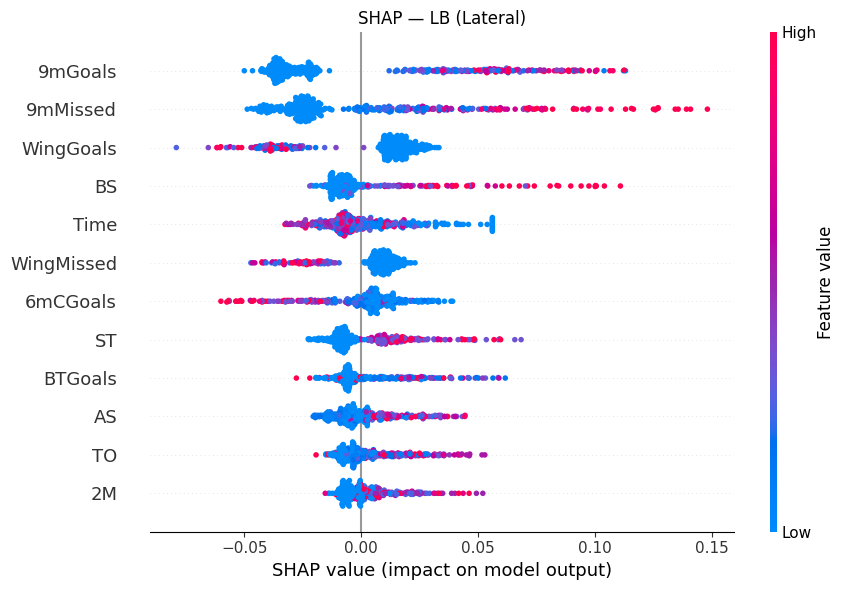

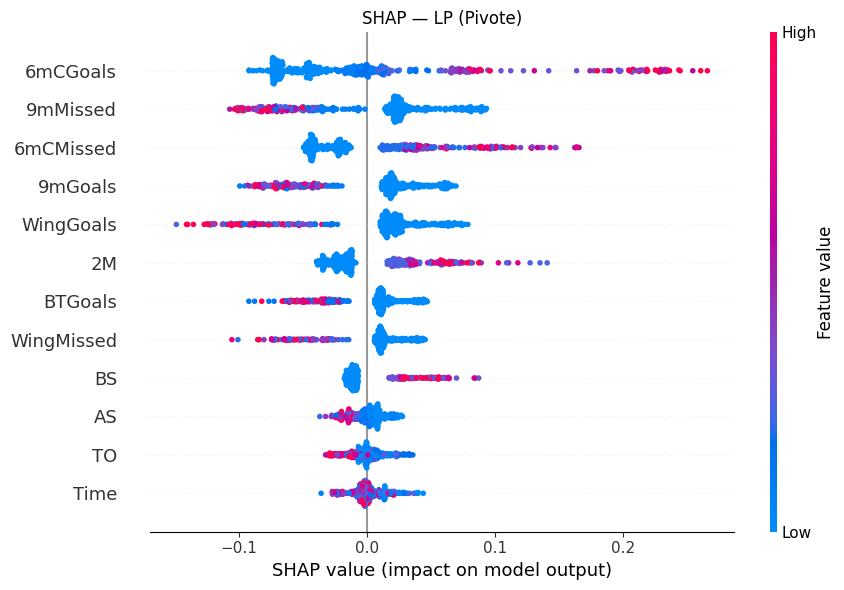

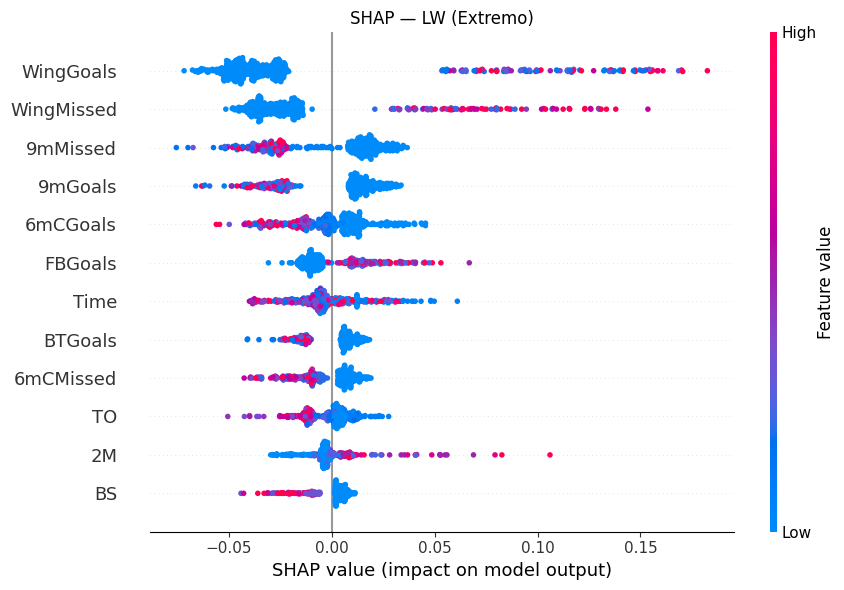

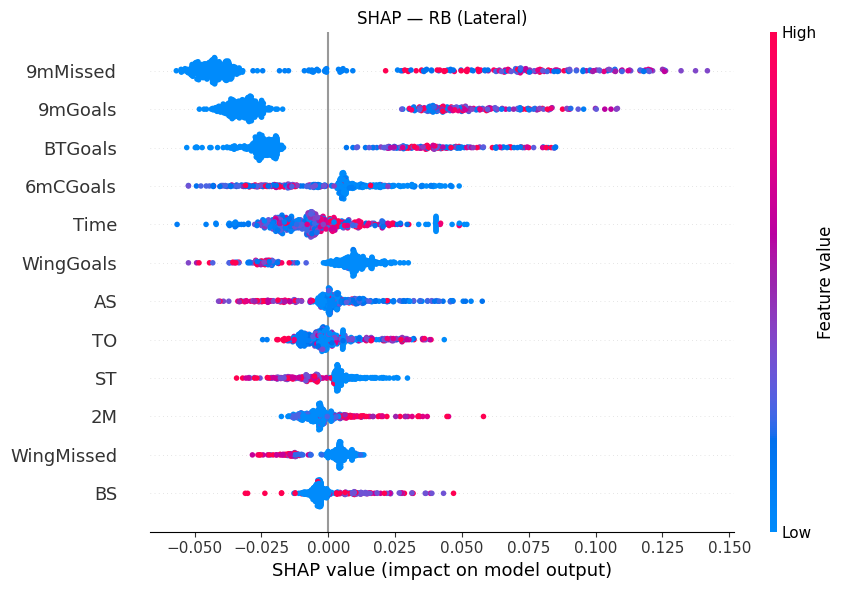

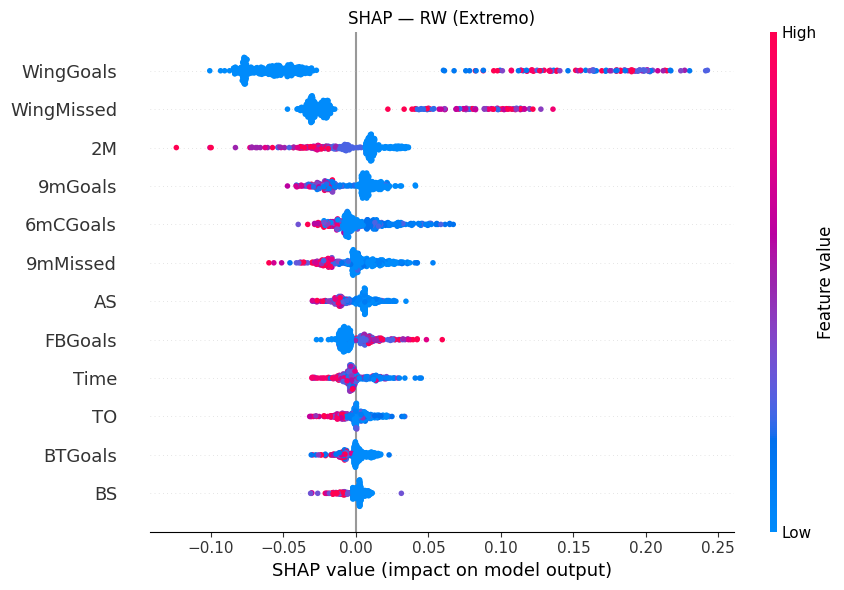

In [31]:
# ── SHAP beeswarm individual por posición ────────────────────
for idx, cls in enumerate(le.classes_):
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.summary_plot(
        shap_list[idx],
        features=X_all_sc,
        feature_names=FEATURE_COLS,
        show=False,
        plot_size=None,
        max_display=12
    )
    plt.title(f'SHAP — {cls} ({POS_GROUP.get(cls, "")})', fontsize=12)
    plt.tight_layout()
    fig.savefig(os.path.join(dir_shap, f'shap_beeswarm_{cls}.png'),
                dpi=130, bbox_inches='tight')
    plt.show()

## 5. Caracterización final de cada posición

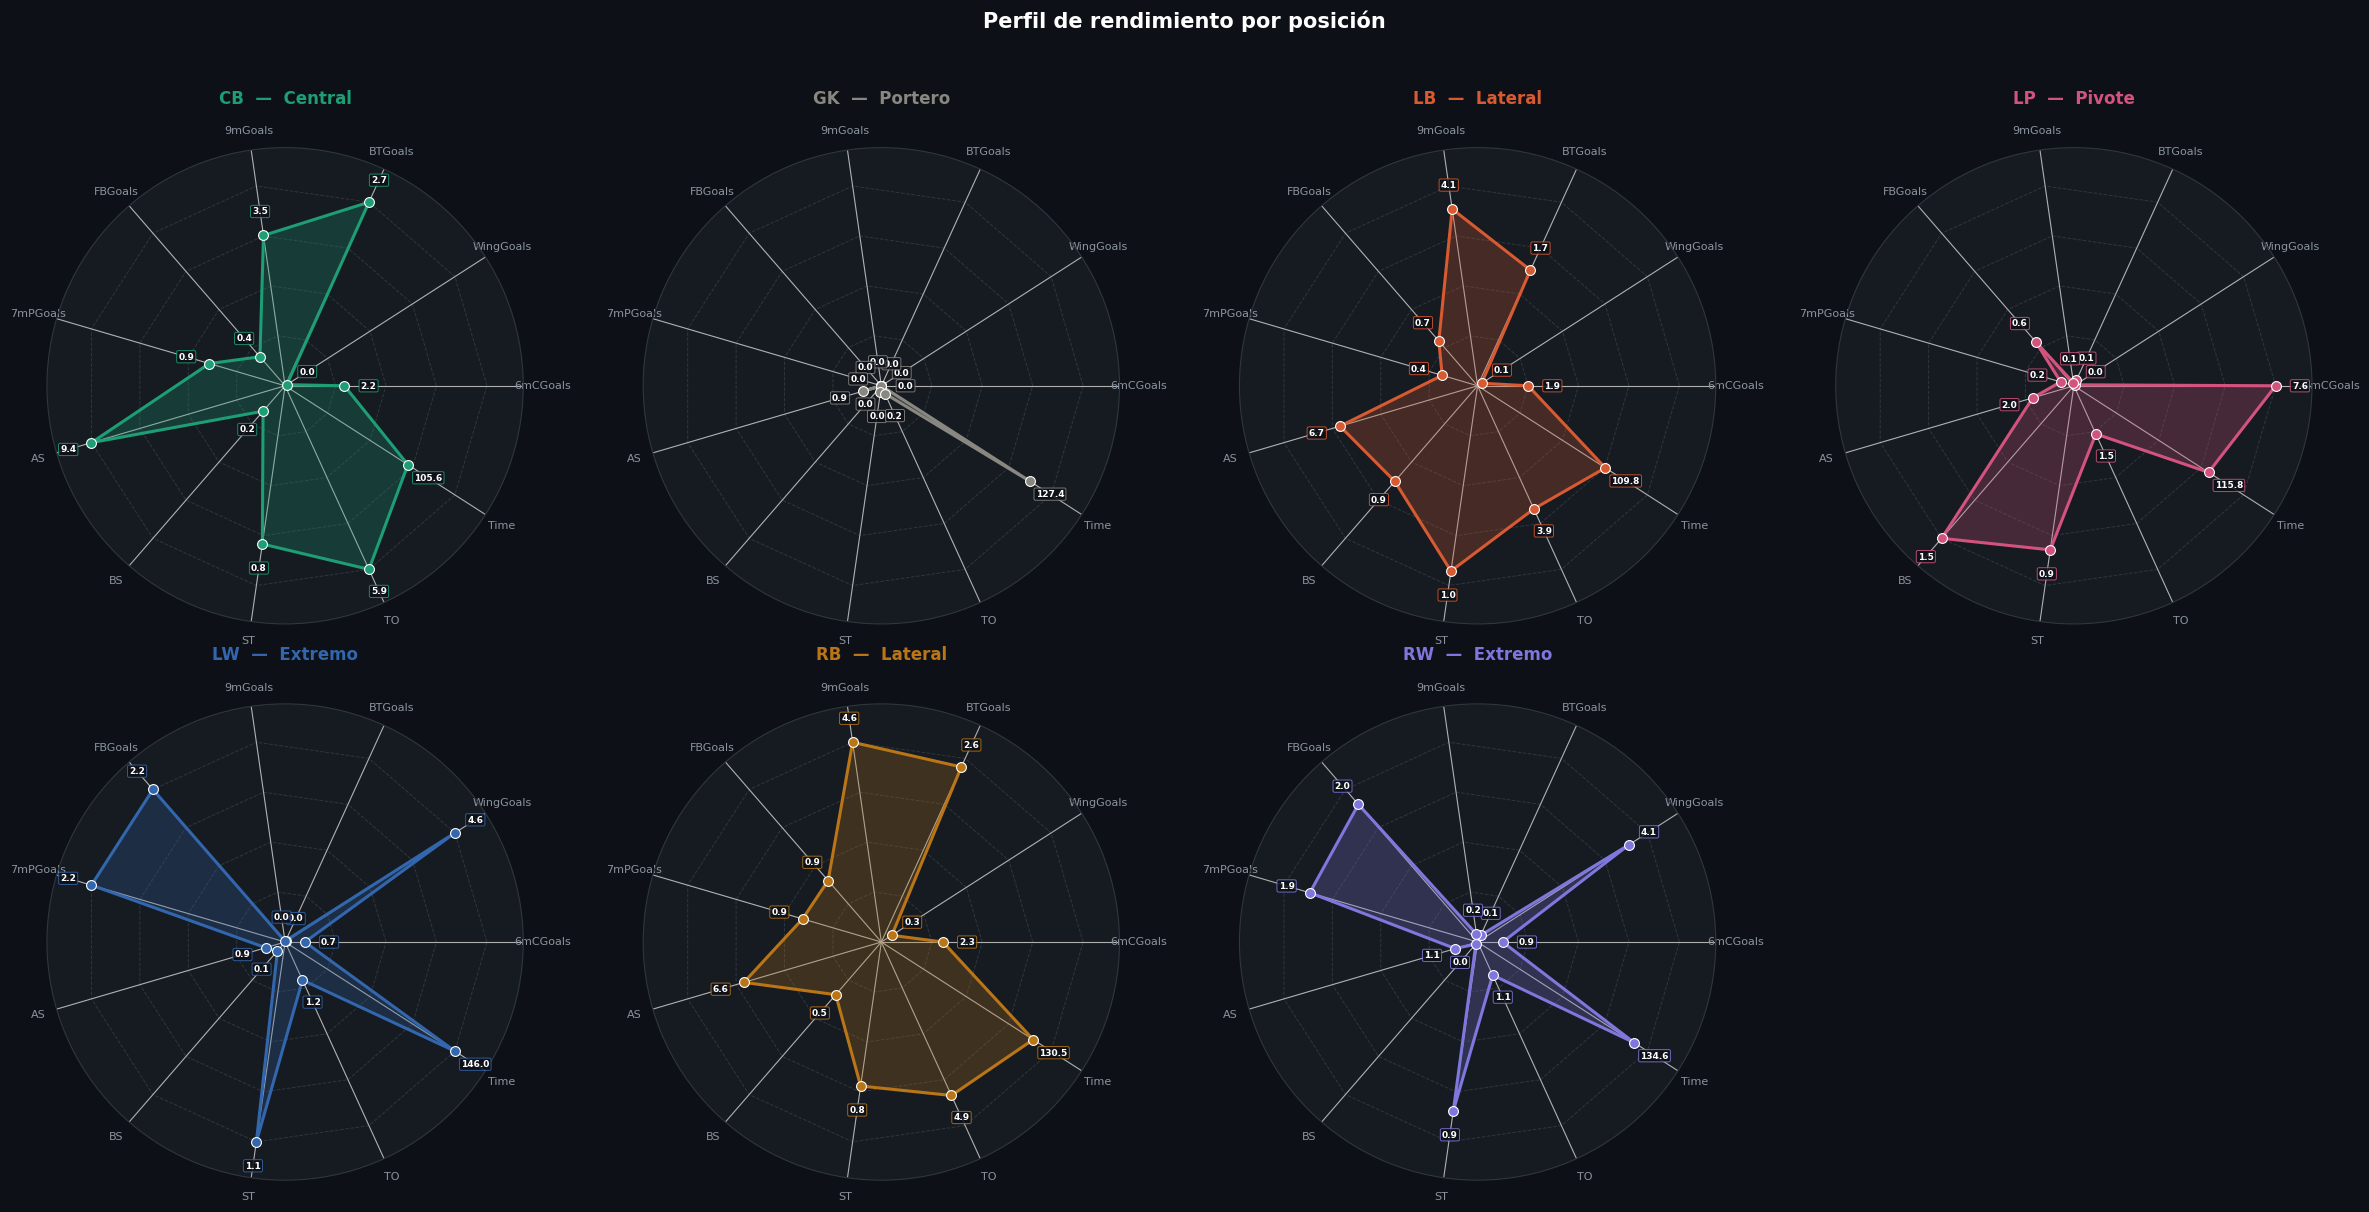

In [32]:
# ── Radar de medias normalizadas por posición ─────────────────
RADAR_VARS = [
    '6mCGoals', 'WingGoals', 'BTGoals', '9mGoals',
    'FBGoals', '7mPGoals', 'AS', 'BS', 'ST', 'TO', 'Time'
]
means_radar = df.groupby(TARGET_COL)[RADAR_VARS].mean()
maxvals = means_radar.max(axis=0)
maxvals[maxvals == 0] = 1
means_norm_radar = means_radar.div(maxvals, axis=1)

n_vars  = len(RADAR_VARS)
angles  = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]
labels_r = [v[:9] if len(v) > 9 else v for v in RADAR_VARS]

positions_list = sorted(df[TARGET_COL].unique())
n_pos   = len(positions_list)
n_pcols = min(n_pos, 4)
n_prows = math.ceil(n_pos / n_pcols)

fig = plt.figure(figsize=(n_pcols * 6, n_prows * 6), facecolor='#0d1117')
fig.suptitle('Perfil de rendimiento por posición',
             fontsize=15, color='white', y=1.0, fontweight='bold')

for pi, pos in enumerate(positions_list):
    color  = POS_COLORS.get(pos, '#888')
    values = means_norm_radar.loc[pos].tolist() + [means_norm_radar.loc[pos].tolist()[0]]
    raw    = means_radar.loc[pos].values

    ax = fig.add_subplot(n_prows, n_pcols, pi + 1, polar=True, facecolor='#161b22')

    for lvl in [0.25, 0.5, 0.75, 1.0]:
        ax.plot(angles, [lvl] * (n_vars + 1),
                color='#30363d', linewidth=0.7, linestyle='--', zorder=1)

    for angle in angles[:-1]:
        ax.plot([angle, angle], [0, 1],
                color='#21262d', linewidth=0.7, zorder=1)

    ax.fill(angles, values, alpha=0.25, color=color, zorder=2)
    ax.plot(angles, values, color=color, linewidth=2.2, zorder=3)
    ax.scatter(angles[:-1], values[:-1],
               s=50, color=color, zorder=4,
               edgecolors='white', linewidths=0.8)

    for ang, val, rv in zip(angles[:-1], values[:-1], raw):
        ax.text(ang, val + 0.12, f'{rv:.1f}',
                fontsize=6.5, color='white',
                ha='center', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.18',
                          facecolor='#0d1117', edgecolor=color,
                          linewidth=0.7, alpha=0.85))

    ax.set_thetagrids(np.degrees(angles[:-1]),
                      labels=labels_r, fontsize=8, color='#8b949e')
    ax.set_title(f'{pos}  —  {POS_GROUP.get(pos, "")}',
                 fontsize=12, fontweight='bold', color=color, pad=16)
    ax.set_ylim(0, 1.18); ax.set_yticks([])
    ax.spines['polar'].set_color('#30363d')

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig('position_output/radar_positions.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [33]:
# ── Tabla de caracterización final ───────────────────────────
print('\n' + '=' * 70)
print('CARACTERIZACIÓN FINAL DE CADA POSICIÓN')
print('=' * 70)

char_rows = []

for pos in le.classes_:
    shap_pos = pos_shap_summary[pos]
    top3_pos = shap_pos[shap_pos['mean_shap'] > 0].head(3).index.tolist()
    top3_neg = shap_pos[shap_pos['mean_shap'] < 0].head(3).index.tolist()

    mean_row = df[df[TARGET_COL] == pos][FEATURE_COLS].mean().round(2)
    max_var  = mean_row.idxmax()

    print(f'\n{pos} — {POS_GROUP.get(pos, "")}')
    print(f'  Variables definitivas (+): {top3_pos}')
    print(f'  Variables ausentes   (−): {top3_neg}')
    print(f'  Variable con mayor media: {max_var} = {mean_row[max_var]}')

    char_rows.append({
        'Posición': pos,
        'Grupo': POS_GROUP.get(pos, ''),
        'Vars_positivas': ', '.join(top3_pos),
        'Vars_negativas': ', '.join(top3_neg),
    })

print('\n' + '=' * 70)

char_df = pd.DataFrame(char_rows)
display(char_df)
char_df.to_csv('position_output/caracterizacion_posiciones.csv', index=False)
print('\nGuardado en position_output/caracterizacion_posiciones.csv')


CARACTERIZACIÓN FINAL DE CADA POSICIÓN

CB — Central
  Variables definitivas (+): ['9mMissed', '9mGoals', 'WingGoals']
  Variables ausentes   (−): ['AS', 'TO', 'Time']
  Variable con mayor media: Time = 105.56

GK — Portero
  Variables definitivas (+): ['Time', 'WingGoals', '9mGoals']
  Variables ausentes   (−): ['6mCGoals', '2M', '9mMissed']
  Variable con mayor media: Time = 127.45

LB — Lateral
  Variables definitivas (+): ['9mGoals', '9mMissed', 'WingGoals']
  Variables ausentes   (−): []
  Variable con mayor media: Time = 109.78

LP — Pivote
  Variables definitivas (+): ['6mCGoals', '6mCMissed', 'WingGoals']
  Variables ausentes   (−): ['9mMissed', '9mGoals', 'BTGoals']
  Variable con mayor media: Time = 115.79

LW — Extremo
  Variables definitivas (+): ['FBGoals', 'BTGoals']
  Variables ausentes   (−): ['WingGoals', 'WingMissed', '9mMissed']
  Variable con mayor media: Time = 145.96

RB — Lateral
  Variables definitivas (+): ['9mMissed', '6mCGoals', 'WingGoals']
  Variables ause

,Posición,Grupo,Vars_positivas,Vars_negativas
0,CB,Central,"9mMissed, 9mGoals, WingGoals","AS, TO, Time"
1,GK,Portero,"Time, WingGoals, 9mGoals","6mCGoals, 2M, 9mMissed"
2,LB,Lateral,"9mGoals, 9mMissed, WingGoals",
3,LP,Pivote,"6mCGoals, 6mCMissed, WingGoals","9mMissed, 9mGoals, BTGoals"
4,LW,Extremo,"FBGoals, BTGoals","WingGoals, WingMissed, 9mMissed"
5,RB,Lateral,"9mMissed, 6mCGoals, WingGoals","9mGoals, BTGoals, Time"
6,RW,Extremo,"6mCGoals, TO","WingGoals, WingMissed, 2M"



Guardado en position_output/caracterizacion_posiciones.csv


In [34]:
# ── Resumen de archivos generados ────────────────────────────
print('\nArchivos generados en position_output/:')
for root, dirs, files in os.walk('position_output'):
    level = root.replace('position_output', '').count(os.sep)
    indent = '  ' * level
    if level == 0:
        print(f'{os.path.basename(root)}/')
    else:
        print(f'{indent}{os.path.basename(root)}/')
    for f in sorted(files):
        print(f'{indent}  {f}')


Archivos generados en position_output/:
position_output/
  caracterizacion_posiciones.csv
  confusion_matrices.png
  radar_positions.png
  shap_global_importance.png
  shap_per_position.png
  shap_summary_beeswarm.png
  shap_per_position/
    shap_CB.csv
    shap_GK.csv
    shap_LB.csv
    shap_LP.csv
    shap_LW.csv
    shap_RB.csv
    shap_RW.csv
    shap_beeswarm_CB.png
    shap_beeswarm_GK.png
    shap_beeswarm_LB.png
    shap_beeswarm_LP.png
    shap_beeswarm_LW.png
    shap_beeswarm_RB.png
    shap_beeswarm_RW.png
